# Project 2: Exploratory Data Analysis

**A consulting-style assessment of e-commerce transaction performance**

DecodeLabs Data Analytics Industrial Training Program

This notebook evaluates data quality, customer behavior, product performance, revenue patterns,
unusual transactions, and commercial opportunities. Every metric and conclusion is calculated
from the supplied workbook.

> **Revenue convention:** `TotalPrice` is treated as **gross order value (GOV)** because the
dataset contains cancelled, returned, pending, shipped, and delivered orders but does not contain
refunds, settlement dates, or recognized-revenue fields. Status-based analysis is used to expose
the difference between booked value and commercially realized value.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")
COLORS = {
    "navy": "#17324D",
    "blue": "#2878B5",
    "teal": "#2A9D8F",
    "gold": "#E9C46A",
    "orange": "#F4A261",
    "red": "#D95D5D",
    "gray": "#6B7280",
}
plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "figure.dpi": 110,
})

def money(value):
    return f"${value:,.2f}"

def pct(value):
    return f"{value:.2f}%"

def annotate_bars(ax, currency=False):
    for patch in ax.patches:
        value = patch.get_width() if patch.get_width() > patch.get_height() else patch.get_height()
        if not np.isfinite(value):
            continue
        label = f"${value/1000:,.1f}K" if currency else f"{value:,.0f}"
        if patch.get_width() > patch.get_height():
            ax.text(patch.get_width(), patch.get_y() + patch.get_height()/2, f" {label}",
                    va="center", fontsize=9)
        else:
            ax.text(patch.get_x() + patch.get_width()/2, patch.get_height(), label,
                    ha="center", va="bottom", fontsize=9)

candidates = [
    Path("Dataset for Data Analytics.xlsx"),
    Path("Project_02") / "Dataset for Data Analytics.xlsx",
]
DATA_PATH = next((path for path in candidates if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Dataset for Data Analytics.xlsx was not found.")

raw_df = pd.read_excel(DATA_PATH)
df = raw_df.copy()
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
text_columns = df.select_dtypes(include="object").columns
df[text_columns] = df[text_columns].apply(lambda col: col.str.strip())
df["CouponUsed"] = df["CouponCode"].notna()
df["CouponCodeFilled"] = df["CouponCode"].fillna("No Coupon")
df["CalculatedTotal"] = df["Quantity"] * df["UnitPrice"]
df["RevenueDifference"] = df["TotalPrice"] - df["CalculatedTotal"]

print(f"Loaded {len(df):,} rows and {raw_df.shape[1]} source columns from: {DATA_PATH}")

Loaded 1,200 rows and 14 source columns from: Dataset for Data Analytics.xlsx


## 1. Project Overview

### Business Context

The data represents an e-commerce transaction database linking orders to customers, products,
quantities, prices, payment methods, fulfillment status, marketing source, cart size, and coupon use.

### Problem Statement

Strategic decisions made directly from raw transactions can be distorted by missing fields,
duplicate records, invalid arithmetic, unusual purchases, incomplete time periods, and the difference
between booked and fulfilled orders. EDA establishes whether the data is decision-ready and reveals
which commercial questions deserve deeper investigation.

### Project Objectives

- Understand customer behavior and repeat purchasing.
- Analyze gross order value and time-based patterns.
- Evaluate product, payment, referral, and status performance.
- Detect and explain anomalies without deleting valid high-value activity.
- Generate evidence-based recommendations for growth, retention, marketing, and product strategy.

### Data Dictionary

In [2]:
data_dictionary = pd.DataFrame([
    ("OrderID", "object", "Unique identifier assigned to each order."),
    ("Date", "datetime64", "Date on which the order was recorded."),
    ("CustomerID", "object", "Identifier for the purchasing customer."),
    ("Product", "object", "Product associated with the transaction."),
    ("Quantity", "integer", "Number of units ordered."),
    ("UnitPrice", "float", "Price charged per unit."),
    ("ShippingAddress", "object", "Destination address supplied for shipping."),
    ("PaymentMethod", "object", "Method used to pay for the order."),
    ("OrderStatus", "object", "Current fulfillment or resolution state."),
    ("TrackingNumber", "object", "Shipment tracking identifier."),
    ("ItemsInCart", "integer", "Number of items present in the cart."),
    ("CouponCode", "object", "Promotion code; blank indicates no coupon."),
    ("ReferralSource", "object", "Acquisition or referral channel."),
    ("TotalPrice", "float", "Gross order value: Quantity multiplied by UnitPrice."),
], columns=["Column Name", "Data Type", "Description"])
display(data_dictionary)

,Column Name,Data Type,Description
0,OrderID,object,Unique identifier assigned to each order.
1,Date,datetime64,Date on which the order was recorded.
2,CustomerID,object,Identifier for the purchasing customer.
3,Product,object,Product associated with the transaction.
4,Quantity,integer,Number of units ordered.
5,UnitPrice,float,Price charged per unit.
6,ShippingAddress,object,Destination address supplied for shipping.
7,PaymentMethod,object,Method used to pay for the order.
8,OrderStatus,object,Current fulfillment or resolution state.
9,TrackingNumber,object,Shipment tracking identifier.


## 2. Data Understanding & Data Quality

This section tests the dataset before analysis. Missingness is separated into true quality risk and
business semantics: an empty coupon code means that no coupon was used, not that the order is unusable.

In [3]:
print(f"Dataset shape: {raw_df.shape[0]:,} rows × {raw_df.shape[1]} columns")
display(pd.DataFrame({
    "Data Type": raw_df.dtypes.astype(str),
    "Non-Null Count": raw_df.notna().sum(),
    "Unique Values": raw_df.nunique(dropna=True),
}))

Dataset shape: 1,200 rows × 14 columns


,Data Type,Non-Null Count,Unique Values
OrderID,object,1200,1200
Date,datetime64[ns],1200,671
CustomerID,object,1200,1189
Product,object,1200,7
Quantity,int64,1200,5
UnitPrice,float64,1200,1193
ShippingAddress,object,1200,655
PaymentMethod,object,1200,5
OrderStatus,object,1200,5
TrackingNumber,object,1200,1200


In [4]:
missing_table = pd.DataFrame({
    "Missing Values": raw_df.isna().sum(),
    "Missing Percentage": raw_df.isna().mean().mul(100),
}).sort_values("Missing Percentage", ascending=False)
display(missing_table)

duplicate_rows = int(raw_df.duplicated().sum())
duplicate_order_ids = int(raw_df["OrderID"].duplicated().sum())
duplicate_tracking = int(raw_df["TrackingNumber"].duplicated().sum())
print(f"Complete duplicate rows: {duplicate_rows}")
print(f"Duplicate OrderID values: {duplicate_order_ids}")
print(f"Duplicate TrackingNumber values: {duplicate_tracking}")
print("Interpretation: CouponCode is the only incomplete field; its blanks are retained and labelled 'No Coupon'.")

,Missing Values,Missing Percentage
CouponCode,309,25.75
OrderID,0,0.00
CustomerID,0,0.00
Product,0,0.00
Quantity,0,0.00
Date,0,0.00
UnitPrice,0,0.00
ShippingAddress,0,0.00
OrderStatus,0,0.00
PaymentMethod,0,0.00


Complete duplicate rows: 0
Duplicate OrderID values: 0
Duplicate TrackingNumber values: 0
Interpretation: CouponCode is the only incomplete field; its blanks are retained and labelled 'No Coupon'.


In [5]:
numeric_checks = {
    "Negative quantities": int((df["Quantity"] < 0).sum()),
    "Zero quantities": int((df["Quantity"] == 0).sum()),
    "Negative unit prices": int((df["UnitPrice"] < 0).sum()),
    "Zero unit prices": int((df["UnitPrice"] == 0).sum()),
    "Negative total prices": int((df["TotalPrice"] < 0).sum()),
    "Zero total prices": int((df["TotalPrice"] == 0).sum()),
    "Invalid cart sizes": int((df["ItemsInCart"] <= 0).sum()),
    "Invalid dates": int(df["Date"].isna().sum()),
    "Revenue arithmetic mismatches": int(
        (~np.isclose(df["TotalPrice"], df["CalculatedTotal"], atol=0.01)).sum()
    ),
}
display(pd.DataFrame.from_dict(numeric_checks, orient="index", columns=["Issue Count"]))

completeness = 100 * (
    raw_df.drop(columns=["CouponCode"]).notna().sum().sum()
    + raw_df["CouponCode"].fillna("No Coupon").notna().sum()
) / raw_df.size
uniqueness = 100 * df["OrderID"].nunique() / len(df)
validity = 100 * (1 - sum(numeric_checks.values()) / (len(df) * len(numeric_checks)))
consistency = 100 * np.isclose(
    df["TotalPrice"], df["CalculatedTotal"], atol=0.01
).mean()

scorecard = pd.DataFrame([
    ("Completeness", completeness, "Pass", "All required fields populated; blank coupons mean no promotion."),
    ("Uniqueness", uniqueness, "Pass" if uniqueness == 100 else "Review",
     "Order IDs are unique; duplicate rows are reported separately."),
    ("Validity", validity, "Pass" if validity == 100 else "Review",
     "Dates and numeric business rules were tested."),
    ("Consistency", consistency, "Pass" if consistency == 100 else "Review",
     "TotalPrice was reconciled to Quantity × UnitPrice."),
], columns=["Metric", "Result (%)", "Status", "Business Interpretation"])
display(scorecard.style.format({"Result (%)": "{:.2f}%"}))

print(
    "Business interpretation: the dataset is analysis-ready. Coupon blanks are analytically meaningful, "
    "and no cleaning decision requires deleting source records."
)

,Issue Count
Negative quantities,0
Zero quantities,0
Negative unit prices,0
Zero unit prices,0
Negative total prices,0
Zero total prices,0
Invalid cart sizes,0
Invalid dates,0
Revenue arithmetic mismatches,0


,Metric,Result (%),Status,Business Interpretation
0,Completeness,100.00%,Pass,All required fields populated; blank coupons mean no promotion.
1,Uniqueness,100.00%,Pass,Order IDs are unique; duplicate rows are reported separately.
2,Validity,100.00%,Pass,Dates and numeric business rules were tested.
3,Consistency,100.00%,Pass,TotalPrice was reconciled to Quantity × UnitPrice.


Business interpretation: the dataset is analysis-ready. Coupon blanks are analytically meaningful, and no cleaning decision requires deleting source records.


## 3. Descriptive Statistics

The expanded statistics table covers central tendency, dispersion, shape, and quartiles. The business
interpretation underneath each variable explains how these numbers affect decision-making.

In [6]:
analysis_numeric = ["Quantity", "UnitPrice", "TotalPrice", "ItemsInCart"]
rows = []
for column in analysis_numeric:
    series = df[column].dropna()
    rows.append({
        "Variable": column,
        "Count": series.count(),
        "Mean": series.mean(),
        "Median": series.median(),
        "Mode": series.mode().iloc[0],
        "Std Dev": series.std(),
        "Variance": series.var(),
        "Minimum": series.min(),
        "Maximum": series.max(),
        "Q1": series.quantile(0.25),
        "Q2": series.quantile(0.50),
        "Q3": series.quantile(0.75),
        "IQR": series.quantile(0.75) - series.quantile(0.25),
        "Skewness": series.skew(),
        "Kurtosis": series.kurtosis(),
    })
descriptive_stats = pd.DataFrame(rows).set_index("Variable")
display(descriptive_stats)

,Count,Mean,Median,Mode,Std Dev,Variance,Minimum,Maximum,Q1,Q2,Q3,IQR,Skewness,Kurtosis
Variable,,,,,,,,,,,,,,
Quantity,1200,2.95,3.00,1.00,1.41,1.98,1.00,5.00,2.00,3.00,4.00,2.00,0.03,-1.29
UnitPrice,1200,356.41,364.21,127.18,197.18,"38,878.83",11.39,699.93,186.06,364.21,521.57,335.51,-0.03,-1.19
TotalPrice,1200,"1,053.97",823.62,211.14,819.86,"672,164.78",11.39,"3,456.40",410.52,823.62,"1,578.47","1,167.95",0.89,-0.04
ItemsInCart,1200,5.49,5.00,5.00,2.28,5.21,1.00,10.00,4.00,5.00,7.00,3.00,0.00,-0.71


In [7]:
q = descriptive_stats
interpretations = {
    "Quantity": (
        f"Orders contain {q.loc['Quantity','Mean']:.2f} units on average and a median of "
        f"{q.loc['Quantity','Median']:.0f}. Near-zero skewness indicates balanced demand across "
        f"the observed 1–5 unit range; there is no long tail of extreme bulk quantities."
    ),
    "UnitPrice": (
        f"The typical unit price is around {money(q.loc['UnitPrice','Median'])}, with a wide "
        f"{money(q.loc['UnitPrice','IQR'])} middle-50% range. The distribution is nearly symmetric, "
        "so both value and premium price points are materially represented."
    ),
    "TotalPrice": (
        f"Average order value ({money(q.loc['TotalPrice','Mean'])}) exceeds the median "
        f"({money(q.loc['TotalPrice','Median'])}). Skewness of {q.loc['TotalPrice','Skewness']:.2f} "
        "shows that a smaller group of high-value purchases lifts the average."
    ),
    "ItemsInCart": (
        f"Carts contain a median of {q.loc['ItemsInCart','Median']:.0f} items and are centered around "
        f"{q.loc['ItemsInCart','Mean']:.2f}. The broad 1–10 range creates room to study cart conversion, "
        "although item-level abandonment cannot be measured from the available fields."
    ),
}
for variable, interpretation in interpretations.items():
    display(Markdown(f"**{variable} — business meaning:** {interpretation}"))

**Quantity — business meaning:** Orders contain 2.95 units on average and a median of 3. Near-zero skewness indicates balanced demand across the observed 1–5 unit range; there is no long tail of extreme bulk quantities.

**UnitPrice — business meaning:** The typical unit price is around $364.21, with a wide $335.51 middle-50% range. The distribution is nearly symmetric, so both value and premium price points are materially represented.

**TotalPrice — business meaning:** Average order value ($1,053.97) exceeds the median ($823.62). Skewness of 0.89 shows that a smaller group of high-value purchases lifts the average.

**ItemsInCart — business meaning:** Carts contain a median of 5 items and are centered around 5.49. The broad 1–10 range creates room to study cart conversion, although item-level abandonment cannot be measured from the available fields.

## 4. Univariate Analysis

Histograms and KDE curves show distribution shape, while boxplots make spread and unusual values
visible. Each variable is interpreted as a customer-behavior signal rather than as a chart alone.

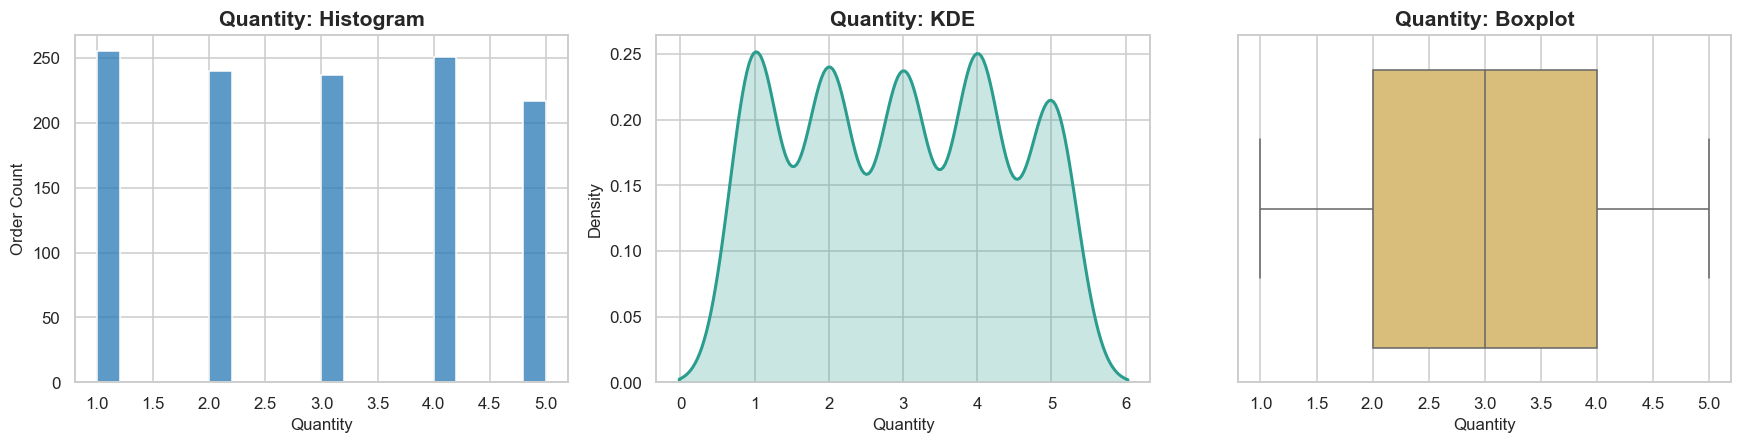

Distribution analysis — Quantity: approximately symmetric; skewness=0.03, IQR=2.00. Customer story: Customers buy across the full 1–5 unit range, with no evidence that very large bulk orders dominate.


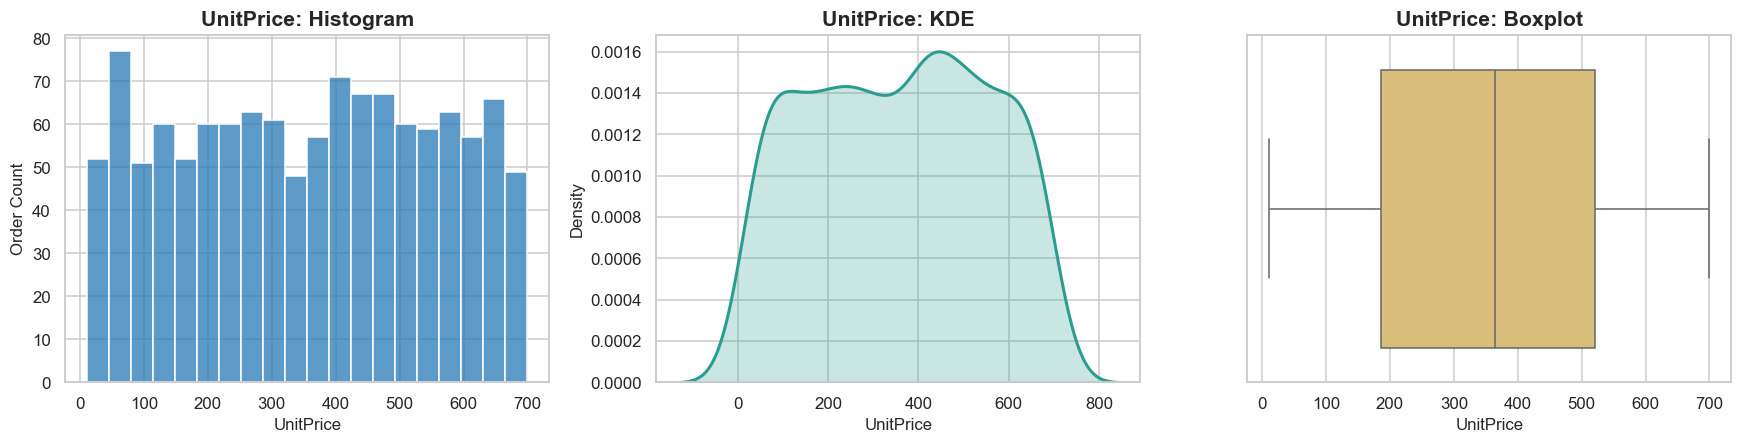

Distribution analysis — UnitPrice: approximately symmetric; skewness=-0.03, IQR=335.51. Customer story: Demand spans low and high price points; purchasing is not concentrated in a narrow price band.


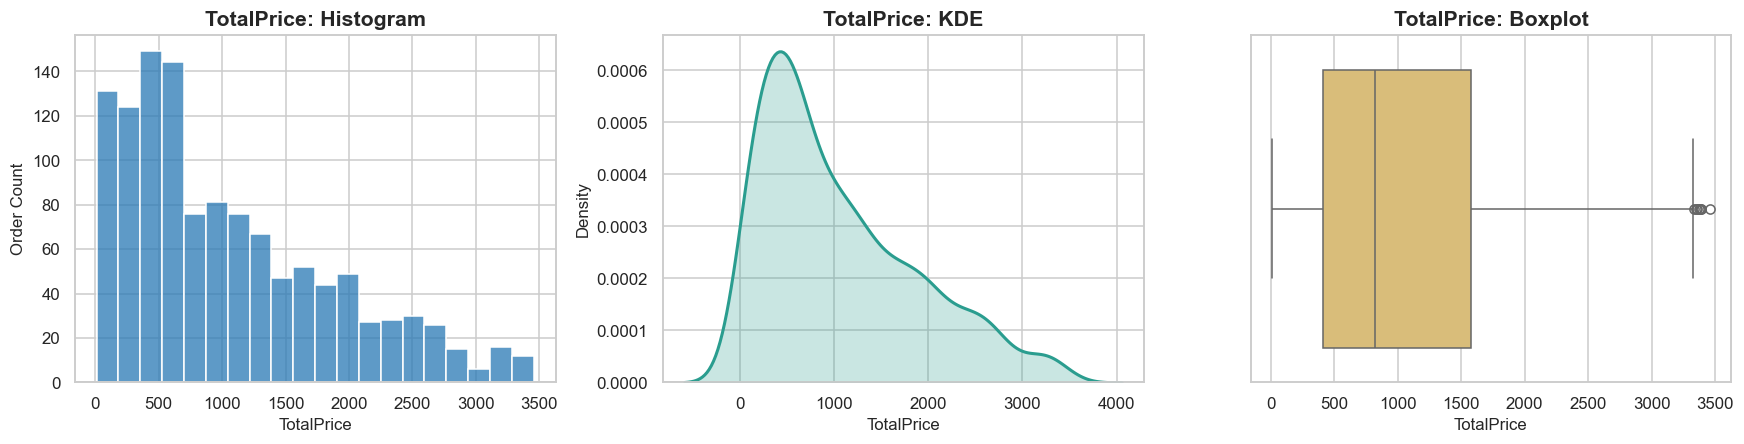

Distribution analysis — TotalPrice: right-skewed; skewness=0.89, IQR=1,167.95. Customer story: Most orders sit below the mean, while valid high-value orders form a commercially important right tail.


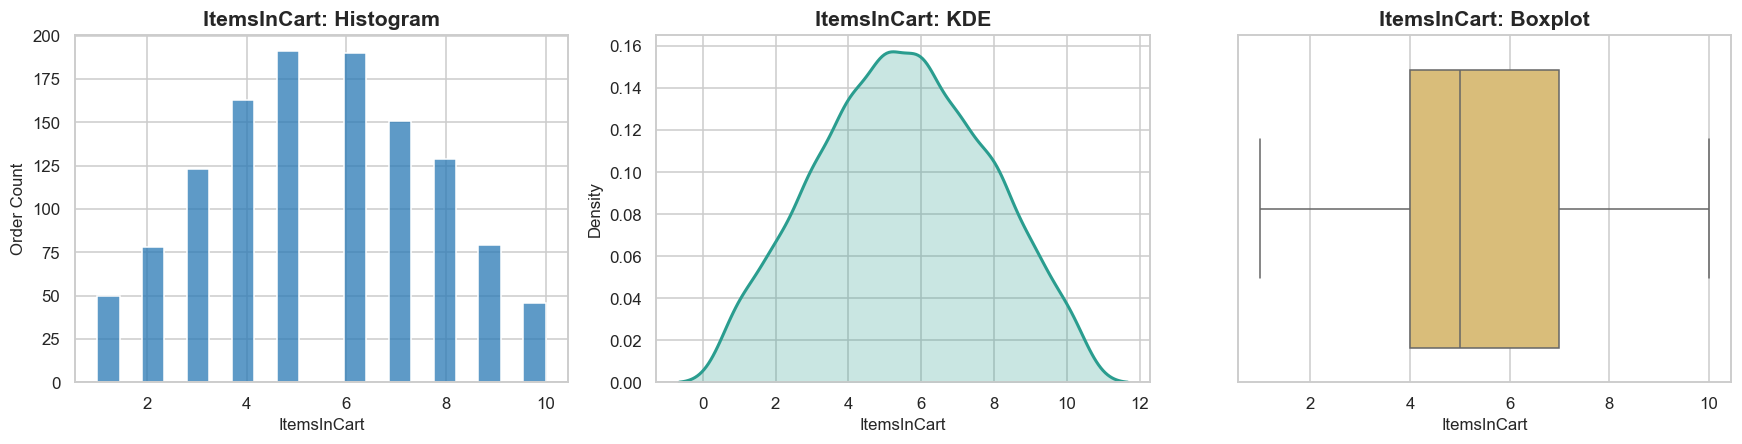

Distribution analysis — ItemsInCart: approximately symmetric; skewness=0.00, IQR=3.00. Customer story: Cart sizes are centered near five items, suggesting cross-sell potential around mid-sized baskets.


In [8]:
distribution_stories = {
    "Quantity": "Customers buy across the full 1–5 unit range, with no evidence that very large bulk orders dominate.",
    "UnitPrice": "Demand spans low and high price points; purchasing is not concentrated in a narrow price band.",
    "TotalPrice": "Most orders sit below the mean, while valid high-value orders form a commercially important right tail.",
    "ItemsInCart": "Cart sizes are centered near five items, suggesting cross-sell potential around mid-sized baskets.",
}

for column in analysis_numeric:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
    sns.histplot(df[column], bins=20, ax=axes[0], color=COLORS["blue"], edgecolor="white")
    axes[0].set_title(f"{column}: Histogram")
    axes[0].set_ylabel("Order Count")

    sns.kdeplot(df[column], fill=True, ax=axes[1], color=COLORS["teal"], linewidth=2)
    axes[1].set_title(f"{column}: KDE")
    axes[1].set_ylabel("Density")

    sns.boxplot(x=df[column], ax=axes[2], color=COLORS["gold"])
    axes[2].set_title(f"{column}: Boxplot")
    axes[2].set_xlabel(column)
    plt.tight_layout()
    plt.show()

    series = df[column]
    shape = "right-skewed" if series.skew() > 0.5 else (
        "left-skewed" if series.skew() < -0.5 else "approximately symmetric"
    )
    print(
        f"Distribution analysis — {column}: {shape}; skewness={series.skew():.2f}, "
        f"IQR={series.quantile(.75)-series.quantile(.25):,.2f}. "
        f"Customer story: {distribution_stories[column]}"
    )

## 5. Outlier Analysis

Outliers are compared using two definitions:

- **IQR:** observations below Q1 − 1.5×IQR or above Q3 + 1.5×IQR.
- **Z-score:** observations more than three standard deviations from the mean.

Records are retained. In transactional data, an unusual value may represent a premium sale or valuable
customer rather than an error.

In [9]:
outlier_summary = []
outlier_masks = {}
for column in analysis_numeric:
    series = df[column]
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    iqr_mask = (series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)
    z_values = np.abs(stats.zscore(series, nan_policy="omit"))
    z_mask = pd.Series(z_values > 3, index=df.index)
    outlier_masks[(column, "IQR")] = iqr_mask
    outlier_masks[(column, "Z-Score")] = z_mask
    outlier_summary.extend([
        (column, "IQR", int(iqr_mask.sum()), 100 * iqr_mask.mean()),
        (column, "Z-Score", int(z_mask.sum()), 100 * z_mask.mean()),
    ])

outlier_comparison = pd.DataFrame(
    outlier_summary,
    columns=["Variable", "Method", "Outlier Count", "Outlier Percentage"]
)
display(outlier_comparison.style.format({"Outlier Percentage": "{:.2f}%"}))

iqr_any = pd.Series(False, index=df.index)
z_any = pd.Series(False, index=df.index)
for column in analysis_numeric:
    iqr_any |= outlier_masks[(column, "IQR")]
    z_any |= outlier_masks[(column, "Z-Score")]

print(f"Unique rows flagged by IQR: {iqr_any.sum():,}")
print(f"Unique rows flagged by Z-score: {z_any.sum():,}")

,Variable,Method,Outlier Count,Outlier Percentage
0,Quantity,IQR,0,0.00%
1,Quantity,Z-Score,0,0.00%
2,UnitPrice,IQR,0,0.00%
3,UnitPrice,Z-Score,0,0.00%
4,TotalPrice,IQR,8,0.67%
5,TotalPrice,Z-Score,0,0.00%
6,ItemsInCart,IQR,0,0.00%
7,ItemsInCart,Z-Score,0,0.00%


Unique rows flagged by IQR: 8
Unique rows flagged by Z-score: 0


In [10]:
customer_metrics_for_classification = df.groupby("CustomerID").agg(
    CustomerOrders=("OrderID", "count"),
    CustomerValue=("TotalPrice", "sum"),
)
classification_df = df.loc[iqr_any | z_any].copy()
classification_df = classification_df.join(customer_metrics_for_classification, on="CustomerID")
value_95 = customer_metrics_for_classification["CustomerValue"].quantile(0.95)
price_q3 = df["UnitPrice"].quantile(0.75)

def classify_outlier(row):
    if (
        row["Quantity"] <= 0
        or row["UnitPrice"] <= 0
        or not np.isclose(row["TotalPrice"], row["CalculatedTotal"], atol=0.01)
    ):
        return "Data Error"
    if row["CustomerOrders"] > 1 and row["CustomerValue"] >= value_95:
        return "VIP Customer"
    if outlier_masks[("Quantity", "IQR")].loc[row.name]:
        return "Bulk Purchase"
    if outlier_masks[("TotalPrice", "IQR")].loc[row.name] and row["UnitPrice"] >= price_q3:
        return "Premium Transaction"
    return "Exceptional Event"

if not classification_df.empty:
    classification_df["Business Classification"] = classification_df.apply(classify_outlier, axis=1)
    outlier_columns = [
        "OrderID", "CustomerID", "Product", "Quantity", "UnitPrice", "TotalPrice",
        "ItemsInCart", "OrderStatus", "Business Classification"
    ]
    display(classification_df[outlier_columns].sort_values("TotalPrice", ascending=False))
    display(
        classification_df["Business Classification"]
        .value_counts()
        .rename_axis("Classification")
        .to_frame("Count")
    )
else:
    print("No observations were flagged by either method.")

print(
    "Decision: retain all flagged records. Their totals reconcile exactly and their values are explained "
    "by valid combinations of quantity and price. Method disagreement also shows why statistical flags "
    "must be reviewed in business context."
)

,OrderID,CustomerID,Product,Quantity,UnitPrice,TotalPrice,ItemsInCart,OrderStatus,Business Classification
789,ORD200789,C57276,Tablet,5,691.28,"3,456.40",10,Delivered,Premium Transaction
1122,ORD201122,C38840,Monitor,5,678.19,"3,390.95",8,Returned,VIP Customer
632,ORD200632,C67260,Laptop,5,678.16,"3,390.80",7,Delivered,Premium Transaction
469,ORD200469,C13877,Chair,5,676.98,"3,384.90",5,Cancelled,Premium Transaction
328,ORD200328,C18404,Tablet,5,674.04,"3,370.20",7,Cancelled,Premium Transaction
107,ORD200107,C16775,Printer,5,670.75,"3,353.75",8,Shipped,Premium Transaction
326,ORD200326,C65986,Laptop,5,670.48,"3,352.40",5,Returned,Premium Transaction
1065,ORD201065,C47778,Printer,5,666.80,"3,334.00",7,Delivered,Premium Transaction


,Count
Classification,
Premium Transaction,7
VIP Customer,1


Decision: retain all flagged records. Their totals reconcile exactly and their values are explained by valid combinations of quantity and price. Method disagreement also shows why statistical flags must be reviewed in business context.


## 6. Product Analysis

Product performance is evaluated by units, gross order value, average order value, and contribution.
A Pareto view tests whether the business relies on a narrow product set.

,Orders,Units,GrossOrderValue,AverageOrderValue,RevenueContributionPct,CumulativeContributionPct
Product,,,,,,
Chair,178,562,"195,620.11","1,098.99",15.47,15.47
Printer,181,542,"195,612.61","1,080.73",15.47,30.93
Laptop,173,535,"192,126.56","1,110.56",15.19,46.12
Tablet,179,497,"186,568.95","1,042.28",14.75,60.88
Monitor,163,480,"175,651.41","1,077.62",13.89,74.76
Desk,170,508,"167,459.93",985.06,13.24,88.00
Phone,156,411,"151,722.39",972.58,12.00,100.00


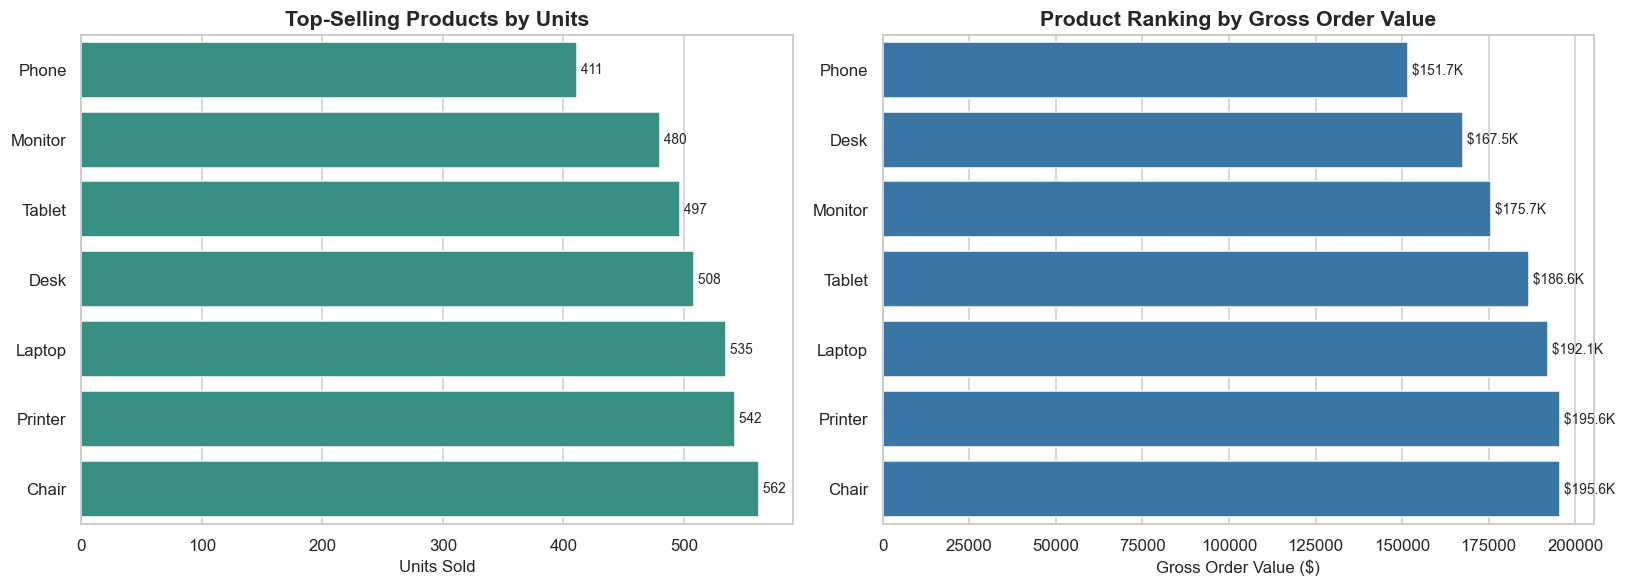

Decision: protect availability and positioning for Chair, the GOV leader at $195,620.11. Investigate Phone, the lowest-GOV product at $151,722.39, through pricing, conversion, and margin analysis.


In [11]:
product = (
    df.groupby("Product")
    .agg(
        Orders=("OrderID", "count"),
        Units=("Quantity", "sum"),
        GrossOrderValue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean"),
    )
    .sort_values("GrossOrderValue", ascending=False)
)
product["RevenueContributionPct"] = 100 * product["GrossOrderValue"] / product["GrossOrderValue"].sum()
product["CumulativeContributionPct"] = product["RevenueContributionPct"].cumsum()
display(product)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
units_rank = product.sort_values("Units")
sns.barplot(x=units_rank["Units"], y=units_rank.index, ax=axes[0], color=COLORS["teal"])
axes[0].set_title("Top-Selling Products by Units")
axes[0].set_xlabel("Units Sold")
axes[0].set_ylabel("")
annotate_bars(axes[0])

revenue_rank = product.sort_values("GrossOrderValue")
sns.barplot(x=revenue_rank["GrossOrderValue"], y=revenue_rank.index, ax=axes[1], color=COLORS["blue"])
axes[1].set_title("Product Ranking by Gross Order Value")
axes[1].set_xlabel("Gross Order Value ($)")
axes[1].set_ylabel("")
annotate_bars(axes[1], currency=True)
plt.tight_layout()
plt.show()

lowest = product["GrossOrderValue"].idxmin()
leader = product["GrossOrderValue"].idxmax()
print(
    f"Decision: protect availability and positioning for {leader}, the GOV leader at "
    f"{money(product.loc[leader,'GrossOrderValue'])}. Investigate {lowest}, the lowest-GOV product at "
    f"{money(product.loc[lowest,'GrossOrderValue'])}, through pricing, conversion, and margin analysis."
)

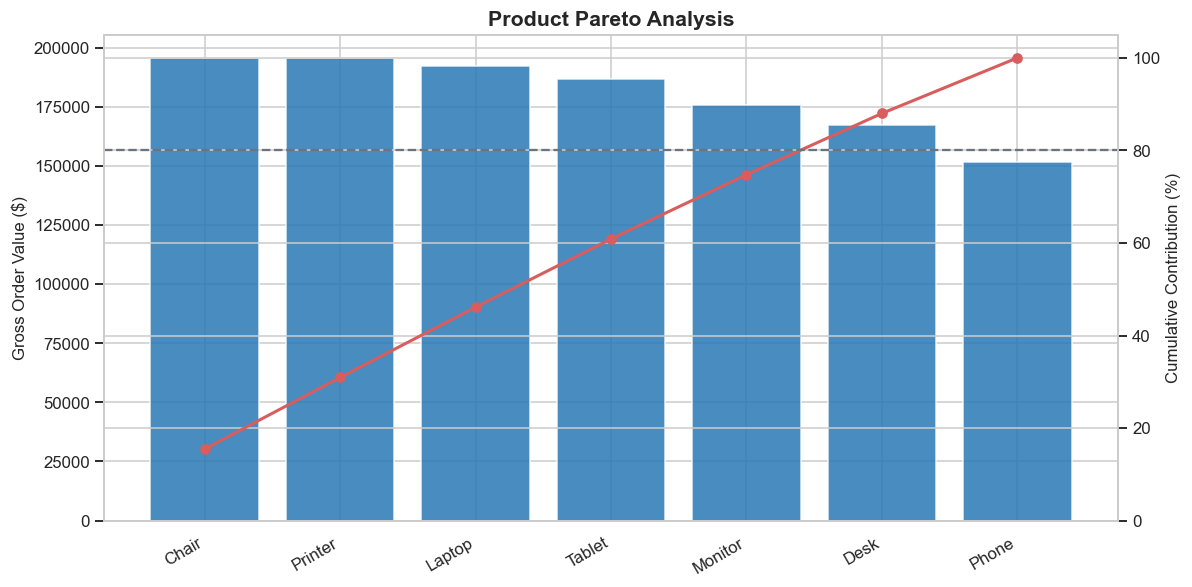

Decision: the top three products contribute 46.12% of GOV. The portfolio is diversified rather than dominated by one SKU, so broad portfolio optimization is more appropriate than a single-product strategy.


In [12]:
fig, ax1 = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(product))
ax1.bar(x, product["GrossOrderValue"], color=COLORS["blue"], alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(product.index, rotation=30, ha="right")
ax1.set_ylabel("Gross Order Value ($)")
ax1.set_title("Product Pareto Analysis")

ax2 = ax1.twinx()
ax2.plot(x, product["CumulativeContributionPct"], color=COLORS["red"], marker="o", linewidth=2)
ax2.axhline(80, color=COLORS["gray"], linestyle="--", linewidth=1.5)
ax2.set_ylabel("Cumulative Contribution (%)")
ax2.set_ylim(0, 105)
plt.tight_layout()
plt.show()

top_three_share = product.head(3)["RevenueContributionPct"].sum()
print(
    f"Decision: the top three products contribute {top_three_share:.2f}% of GOV. "
    "The portfolio is diversified rather than dominated by one SKU, so broad portfolio optimization "
    "is more appropriate than a single-product strategy."
)

## 7. Customer Analysis

Customer revenue approximates historical customer value within the dataset. It is not a predictive
lifetime value model because acquisition dates, margin, churn, and future behavior are unavailable.

In [13]:
customer = (
    df.groupby("CustomerID")
    .agg(
        Orders=("OrderID", "count"),
        CustomerRevenue=("TotalPrice", "sum"),
        Units=("Quantity", "sum"),
        AverageOrderValue=("TotalPrice", "mean"),
        FirstPurchase=("Date", "min"),
        LastPurchase=("Date", "max"),
    )
    .sort_values("CustomerRevenue", ascending=False)
)
customer["RepeatCustomer"] = customer["Orders"] > 1
customer["CLVApproximation"] = customer["CustomerRevenue"]

repeat_count = int(customer["RepeatCustomer"].sum())
repeat_rate = 100 * customer["RepeatCustomer"].mean()
repeat_revenue_share = (
    100 * customer.loc[customer["RepeatCustomer"], "CustomerRevenue"].sum()
    / customer["CustomerRevenue"].sum()
)
top_10_share = 100 * customer.head(10)["CustomerRevenue"].sum() / customer["CustomerRevenue"].sum()
top_20_count = int(np.ceil(len(customer) * 0.20))
top_20_share = 100 * customer.head(top_20_count)["CustomerRevenue"].sum() / customer["CustomerRevenue"].sum()

customer_summary = pd.DataFrame({
    "Metric": [
        "Unique customers", "Repeat customers", "Repeat customer rate",
        "Repeat customer GOV share", "Top 10 customer GOV share", "Top 20% customer GOV share"
    ],
    "Value": [
        f"{len(customer):,}", f"{repeat_count:,}", pct(repeat_rate),
        pct(repeat_revenue_share), pct(top_10_share), pct(top_20_share)
    ]
})
display(customer_summary)
display(customer.head(10))

,Metric,Value
0,Unique customers,"1,189"
1,Repeat customers,11
2,Repeat customer rate,0.93%
3,Repeat customer GOV share,1.54%
4,Top 10 customer GOV share,2.85%
5,Top 20% customer GOV share,45.42%


,Orders,CustomerRevenue,Units,AverageOrderValue,FirstPurchase,LastPurchase,RepeatCustomer,CLVApproximation
CustomerID,,,,,,,,
C38840,2,"5,723.23",9,"2,861.61",2023-06-07,2024-06-08,True,"5,723.23"
C57276,1,"3,456.40",5,"3,456.40",2023-08-17,2023-08-17,False,"3,456.40"
C67260,1,"3,390.80",5,"3,390.80",2023-05-02,2023-05-02,False,"3,390.80"
C13877,1,"3,384.90",5,"3,384.90",2023-11-26,2023-11-26,False,"3,384.90"
C18404,1,"3,370.20",5,"3,370.20",2023-02-28,2023-02-28,False,"3,370.20"
C16775,1,"3,353.75",5,"3,353.75",2023-03-27,2023-03-27,False,"3,353.75"
C65986,1,"3,352.40",5,"3,352.40",2024-07-01,2024-07-01,False,"3,352.40"
C47778,1,"3,334.00",5,"3,334.00",2023-10-30,2023-10-30,False,"3,334.00"
C59183,1,"3,322.55",5,"3,322.55",2023-02-28,2023-02-28,False,"3,322.55"


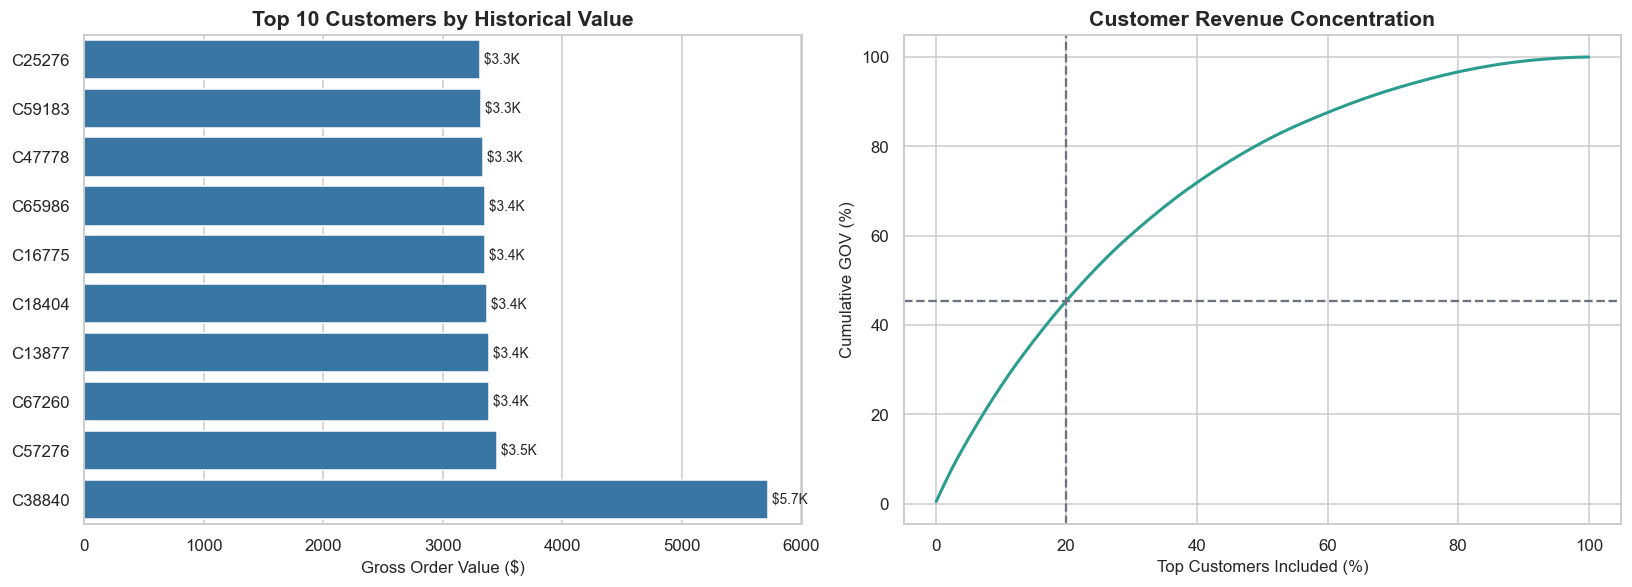

Decision: only 11 customers (0.93%) purchased more than once, generating 1.54% of GOV. The priority is a measurable second-purchase program, while low top-10 concentration (2.85%) means dependency on individual customers is limited.


In [14]:
top_customers = customer.head(10).sort_values("CustomerRevenue")
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.barplot(
    x=top_customers["CustomerRevenue"], y=top_customers.index,
    ax=axes[0], color=COLORS["blue"]
)
axes[0].set_title("Top 10 Customers by Historical Value")
axes[0].set_xlabel("Gross Order Value ($)")
axes[0].set_ylabel("")
annotate_bars(axes[0], currency=True)

concentration = customer["CustomerRevenue"].sort_values(ascending=False).cumsum()
concentration_pct = 100 * concentration / concentration.iloc[-1]
customer_pct = 100 * np.arange(1, len(customer) + 1) / len(customer)
axes[1].plot(customer_pct, concentration_pct.values, color=COLORS["teal"], linewidth=2)
axes[1].axvline(20, color=COLORS["gray"], linestyle="--")
axes[1].axhline(top_20_share, color=COLORS["gray"], linestyle="--")
axes[1].set_title("Customer Revenue Concentration")
axes[1].set_xlabel("Top Customers Included (%)")
axes[1].set_ylabel("Cumulative GOV (%)")
plt.tight_layout()
plt.show()

print(
    f"Decision: only {repeat_count} customers ({repeat_rate:.2f}%) purchased more than once, generating "
    f"{repeat_revenue_share:.2f}% of GOV. The priority is a measurable second-purchase program, while "
    f"low top-10 concentration ({top_10_share:.2f}%) means dependency on individual customers is limited."
)

## 8. Revenue Analysis

Gross order value is segmented by payment method, referral source, and order status. Product results
were analyzed in Section 6. Each view ends with the decision it can support.

In [15]:
def category_performance(column):
    result = (
        df.groupby(column)
        .agg(
            Orders=("OrderID", "count"),
            GrossOrderValue=("TotalPrice", "sum"),
            AverageOrderValue=("TotalPrice", "mean"),
        )
        .sort_values("GrossOrderValue", ascending=False)
    )
    result["ContributionPct"] = 100 * result["GrossOrderValue"] / result["GrossOrderValue"].sum()
    return result

payment = category_performance("PaymentMethod")
referral = category_performance("ReferralSource")
status = category_performance("OrderStatus")
display(Markdown("### Payment Method Performance"))
display(payment)
display(Markdown("### Referral Source Performance"))
display(referral)
display(Markdown("### Order Status Performance"))
display(status)

### Payment Method Performance

,Orders,GrossOrderValue,AverageOrderValue,ContributionPct
PaymentMethod,,,,
Credit Card,234,"263,847.63","1,127.55",20.86
Online,258,"262,442.94","1,017.22",20.75
Cash,246,"259,786.29","1,056.04",20.54
Gift Card,230,"246,323.92","1,070.97",19.48
Debit Card,232,"232,361.18","1,001.56",18.37


### Referral Source Performance

,Orders,GrossOrderValue,AverageOrderValue,ContributionPct
ReferralSource,,,,
Instagram,259,"275,285.45","1,062.88",21.77
Email,250,"261,808.55","1,047.23",20.70
Google,241,"250,441.48","1,039.18",19.80
Facebook,228,"250,410.90","1,098.29",19.80
Referral,222,"226,815.58","1,021.69",17.93


### Order Status Performance

,Orders,GrossOrderValue,AverageOrderValue,ContributionPct
OrderStatus,,,,
Cancelled,250,"276,396.21","1,105.58",21.85
Pending,237,"256,328.15","1,081.55",20.27
Shipped,235,"246,159.58","1,047.49",19.46
Returned,247,"243,277.70",984.93,19.24
Delivered,231,"242,600.32","1,050.22",19.18


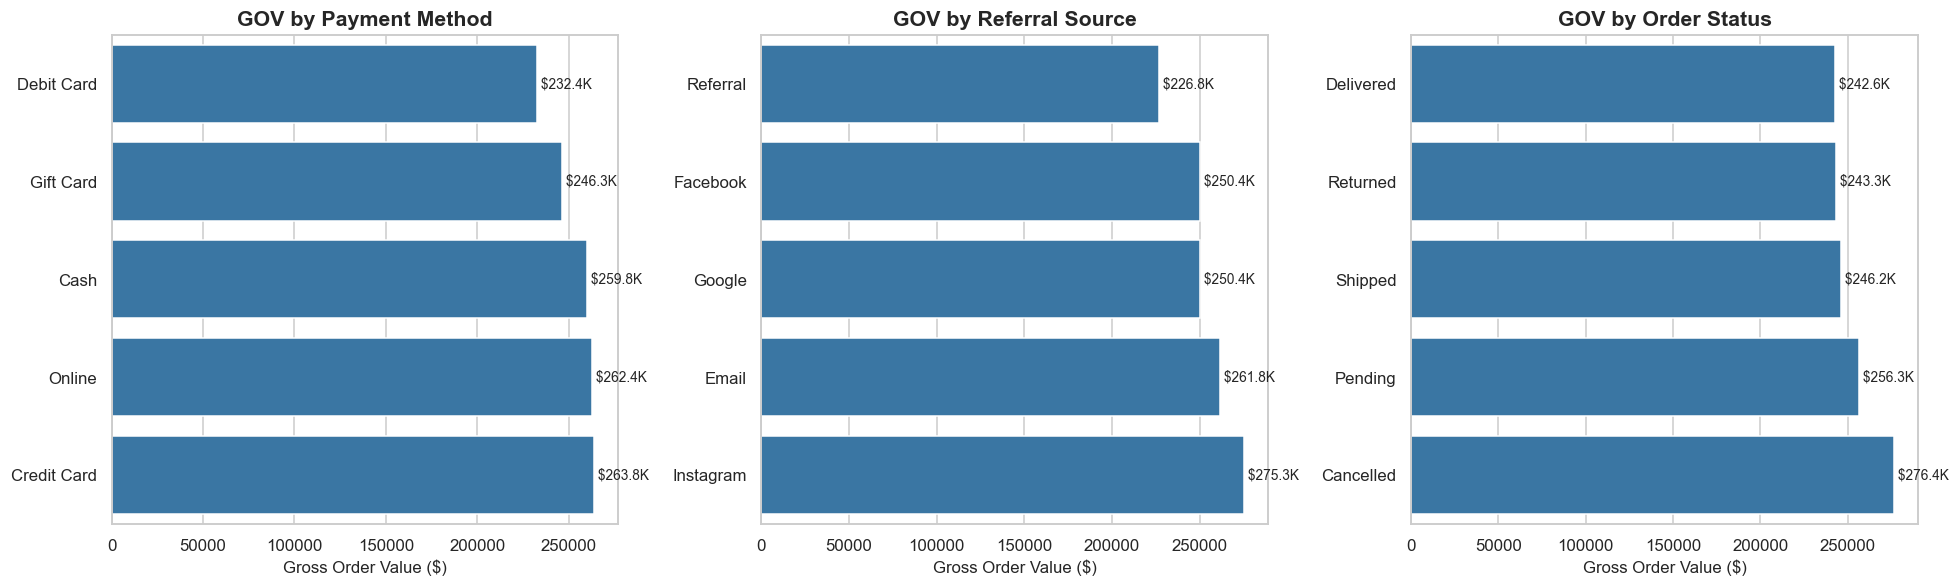

Payment decision: Credit Card has the highest AOV at $1,127.55; test whether checkout placement or incentives can shift suitable customers toward this higher-value behavior.
Marketing decision: Instagram leads GOV, while Facebook leads AOV. Budget allocation should compare both scale and order quality, then be validated against channel cost.
Operations decision: cancelled and returned orders represent $519,673.91 (41.09%) of GOV. Diagnose cancellation and return reasons before treating booked GOV as realized revenue.


In [16]:
analyses = [
    ("Payment Method", payment, "Payment method"),
    ("Referral Source", referral, "Referral source"),
    ("Order Status", status, "Order status"),
]
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (title, table, _) in zip(axes, analyses):
    plot_table = table.sort_values("GrossOrderValue")
    sns.barplot(x=plot_table["GrossOrderValue"], y=plot_table.index, ax=ax, color=COLORS["blue"])
    ax.set_title(f"GOV by {title}")
    ax.set_xlabel("Gross Order Value ($)")
    ax.set_ylabel("")
    annotate_bars(ax, currency=True)
plt.tight_layout()
plt.show()

payment_aov_leader = payment["AverageOrderValue"].idxmax()
referral_gov_leader = referral["GrossOrderValue"].idxmax()
referral_aov_leader = referral["AverageOrderValue"].idxmax()
at_risk = status.loc[status.index.isin(["Cancelled", "Returned"]), "GrossOrderValue"].sum()
at_risk_share = 100 * at_risk / df["TotalPrice"].sum()

print(
    f"Payment decision: {payment_aov_leader} has the highest AOV at "
    f"{money(payment.loc[payment_aov_leader,'AverageOrderValue'])}; test whether checkout placement "
    "or incentives can shift suitable customers toward this higher-value behavior."
)
print(
    f"Marketing decision: {referral_gov_leader} leads GOV, while {referral_aov_leader} leads AOV. "
    "Budget allocation should compare both scale and order quality, then be validated against channel cost."
)
print(
    f"Operations decision: cancelled and returned orders represent {money(at_risk)} "
    f"({at_risk_share:.2f}%) of GOV. Diagnose cancellation and return reasons before treating booked GOV "
    "as realized revenue."
)

In [17]:
coupon = (
    df.groupby("CouponCodeFilled")
    .agg(Orders=("OrderID", "count"), GrossOrderValue=("TotalPrice", "sum"),
         AverageOrderValue=("TotalPrice", "mean"))
    .sort_values("GrossOrderValue", ascending=False)
)
display(coupon)
coupon_users_aov = df.loc[df["CouponUsed"], "TotalPrice"].mean()
no_coupon_aov = df.loc[~df["CouponUsed"], "TotalPrice"].mean()
print(
    f"Coupon decision: coupon orders average {money(coupon_users_aov)} versus "
    f"{money(no_coupon_aov)} without a coupon. This descriptive difference is not causal; "
    "future campaigns should use holdout tests and margin data before increasing discount spend."
)

,Orders,GrossOrderValue,AverageOrderValue
CouponCodeFilled,,,
FREESHIP,313,"335,036.99","1,070.41"
No Coupon,309,"322,401.41","1,043.37"
SAVE10,286,"304,840.02","1,065.87"
WINTER15,292,"302,483.54","1,035.90"


Coupon decision: coupon orders average $1,057.64 versus $1,043.37 without a coupon. This descriptive difference is not causal; future campaigns should use holdout tests and margin data before increasing discount spend.


## 9. Time Series Analysis

Revenue is aggregated daily, weekly, and monthly. A 30-day daily rolling average reduces noise.
The dataset ends on June 30, 2025, so 2025 is a partial year; only like-for-like periods are compared.

In [18]:
time_df = df.set_index("Date").sort_index()
daily = time_df.resample("D").agg(
    Revenue=("TotalPrice", "sum"), Orders=("OrderID", "count")
)
daily["Rolling30DayRevenue"] = daily["Revenue"].rolling(30, min_periods=1).mean()

weekly = time_df.resample("W").agg(
    Revenue=("TotalPrice", "sum"), Orders=("OrderID", "count")
)
monthly = time_df.resample("MS").agg(
    Revenue=("TotalPrice", "sum"), Orders=("OrderID", "count")
)
monthly["GrowthRatePct"] = monthly["Revenue"].pct_change().mul(100)

display(Markdown("### Monthly Revenue, Orders, and Growth"))
display(monthly)

### Monthly Revenue, Orders, and Growth

,Revenue,Orders,GrowthRatePct
Date,,,
2023-01-01,"56,685.75",47,NaN
2023-02-01,"40,117.66",37,-29.23
2023-03-01,"48,609.37",43,21.17
2023-04-01,"27,751.71",31,-42.91
2023-05-01,"63,836.84",49,130.03
2023-06-01,"49,500.19",45,-22.46
2023-07-01,"42,820.66",44,-13.49
2023-08-01,"54,352.14",51,26.93
2023-09-01,"29,526.67",29,-45.68


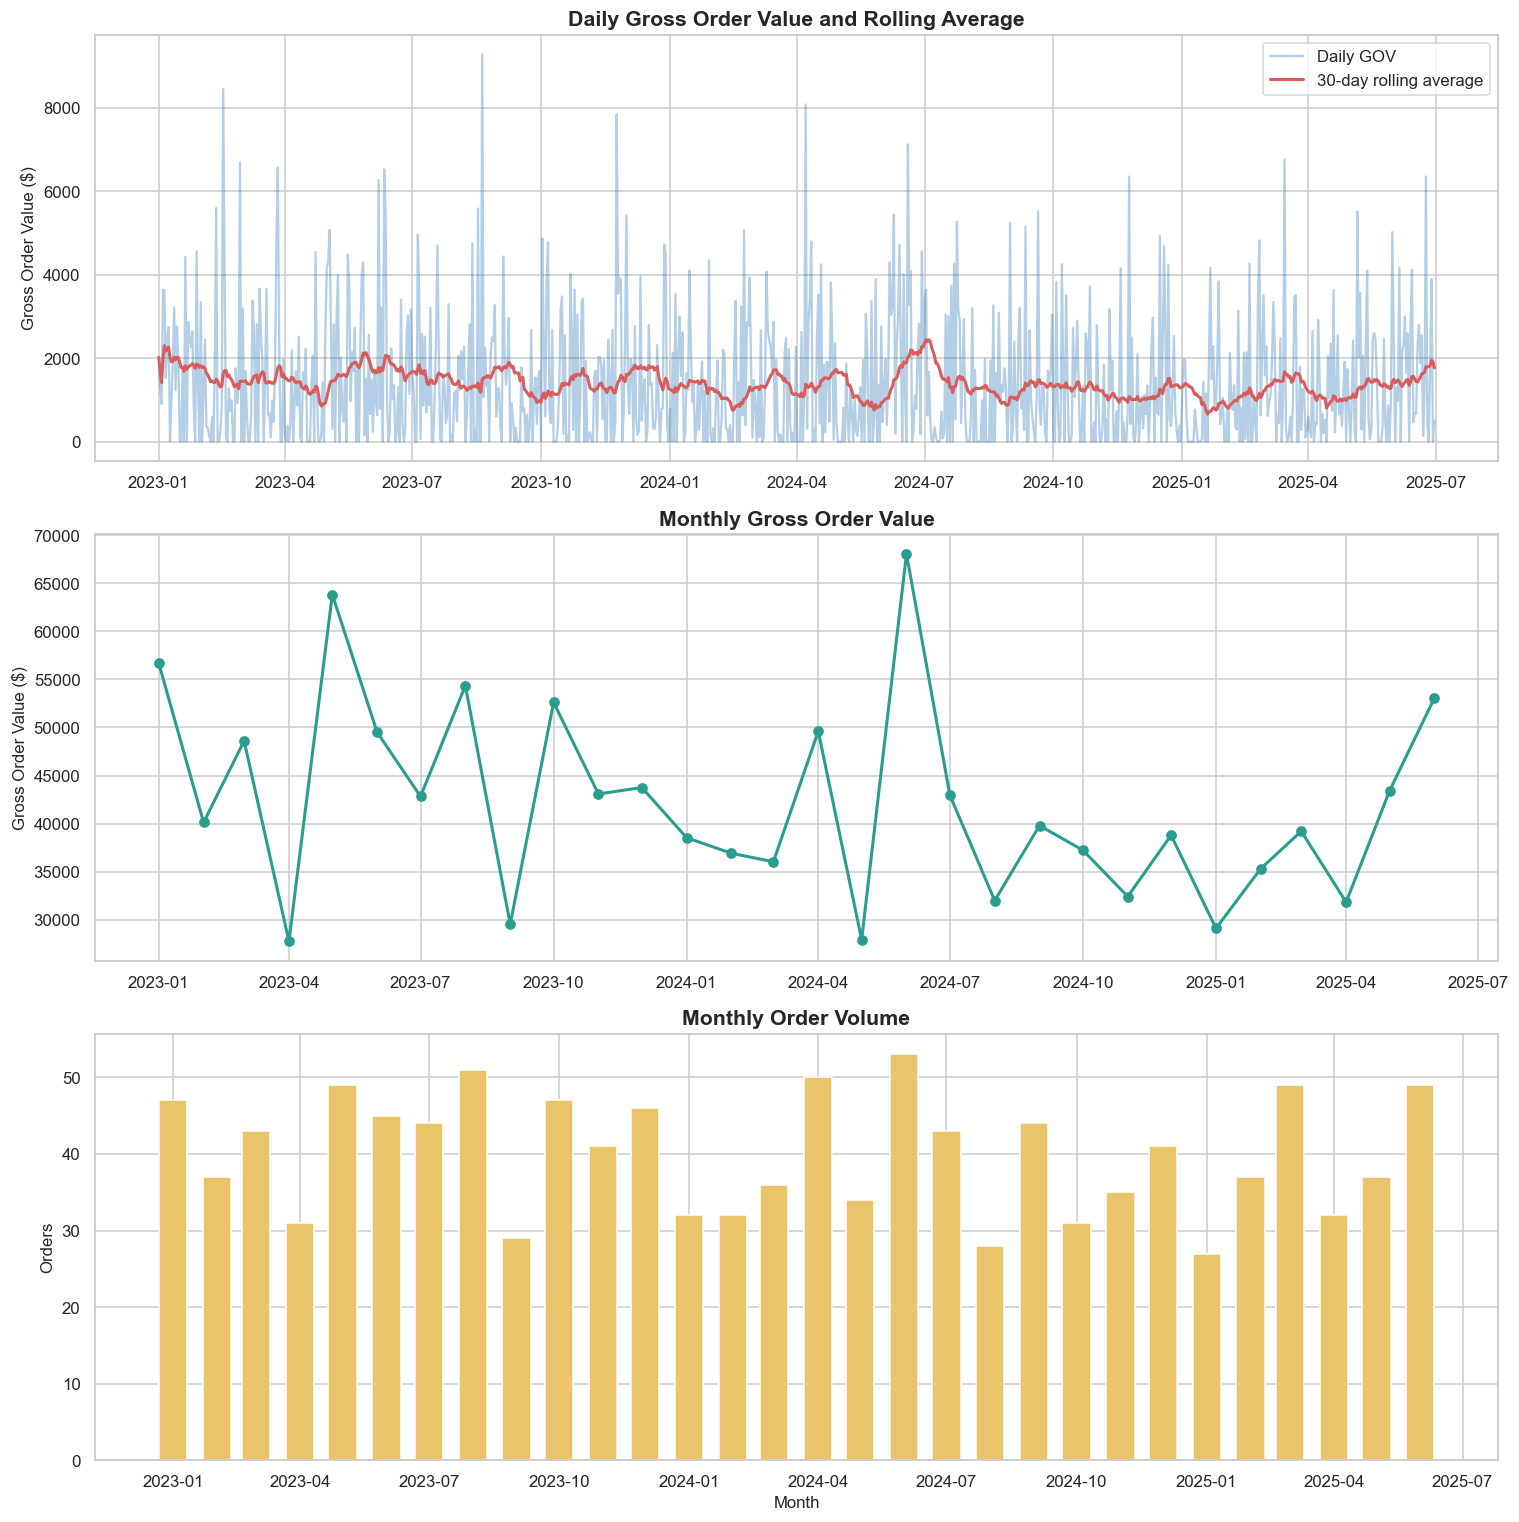

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))
axes[0].plot(daily.index, daily["Revenue"], color=COLORS["blue"], alpha=0.35, label="Daily GOV")
axes[0].plot(
    daily.index, daily["Rolling30DayRevenue"],
    color=COLORS["red"], linewidth=2, label="30-day rolling average"
)
axes[0].set_title("Daily Gross Order Value and Rolling Average")
axes[0].set_ylabel("Gross Order Value ($)")
axes[0].legend()

axes[1].plot(monthly.index, monthly["Revenue"], color=COLORS["teal"], marker="o", linewidth=2)
axes[1].set_title("Monthly Gross Order Value")
axes[1].set_ylabel("Gross Order Value ($)")

axes[2].bar(monthly.index, monthly["Orders"], width=20, color=COLORS["gold"])
axes[2].set_title("Monthly Order Volume")
axes[2].set_ylabel("Orders")
axes[2].set_xlabel("Month")
plt.tight_layout()
plt.show()

In [20]:
peak_month = monthly["Revenue"].idxmax()
low_month = monthly["Revenue"].idxmin()
best_growth_month = monthly["GrowthRatePct"].idxmax()
worst_growth_month = monthly["GrowthRatePct"].idxmin()

annual = df.groupby(df["Date"].dt.year).agg(
    Orders=("OrderID", "count"), Revenue=("TotalPrice", "sum")
)
h1 = (
    df.loc[df["Date"].dt.month <= 6]
    .groupby(df.loc[df["Date"].dt.month <= 6, "Date"].dt.year)
    .agg(Orders=("OrderID", "count"), Revenue=("TotalPrice", "sum"))
)
full_year_change_2024 = 100 * (annual.loc[2024, "Revenue"] / annual.loc[2023, "Revenue"] - 1)
h1_change_2025 = 100 * (h1.loc[2025, "Revenue"] / h1.loc[2024, "Revenue"] - 1)

print(f"Peak month: {peak_month:%B %Y} at {money(monthly.loc[peak_month,'Revenue'])}.")
print(f"Lowest month: {low_month:%B %Y} at {money(monthly.loc[low_month,'Revenue'])}.")
print(
    f"Largest month-over-month increase: {best_growth_month:%B %Y} "
    f"({monthly.loc[best_growth_month,'GrowthRatePct']:.2f}%)."
)
print(
    f"Largest month-over-month decline: {worst_growth_month:%B %Y} "
    f"({monthly.loc[worst_growth_month,'GrowthRatePct']:.2f}%)."
)
print(
    f"Comparable trend: 2024 GOV changed {full_year_change_2024:.2f}% versus 2023; "
    f"H1 2025 changed {h1_change_2025:.2f}% versus H1 2024."
)
print(
    "Decision: investigate operational or campaign changes around peak and decline months, but do not "
    "claim stable seasonality from only two complete years and one partial year."
)

Peak month: June 2024 at $68,068.54.
Lowest month: April 2023 at $27,751.71.
Largest month-over-month increase: June 2024 (143.89%).
Largest month-over-month decline: September 2023 (-45.68%).
Comparable trend: 2024 GOV changed -13.10% versus 2023; H1 2025 changed -9.79% versus H1 2024.
Decision: investigate operational or campaign changes around peak and decline months, but do not claim stable seasonality from only two complete years and one partial year.


## 10. Relationship Analysis

Pearson correlation measures linear relationships, not causation. Because `TotalPrice` is mathematically
defined as `Quantity × UnitPrice`, strong relationships with those inputs are expected and should not be
presented as independent behavioral discoveries.

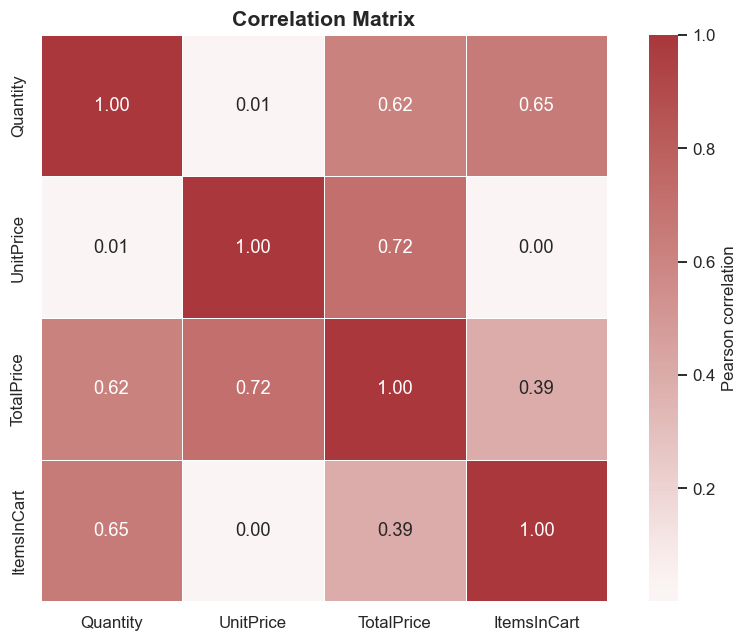

,Quantity,UnitPrice,TotalPrice,ItemsInCart
Quantity,1.00,0.01,0.62,0.65
UnitPrice,0.01,1.00,0.72,0.00
TotalPrice,0.62,0.72,1.00,0.39
ItemsInCart,0.65,0.00,0.39,1.00


In [21]:
relationship_columns = ["Quantity", "UnitPrice", "TotalPrice", "ItemsInCart"]
correlation = df[relationship_columns].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation, annot=True, fmt=".2f", cmap="vlag", center=0,
    square=True, linewidths=0.5, cbar_kws={"label": "Pearson correlation"}
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()
display(correlation)

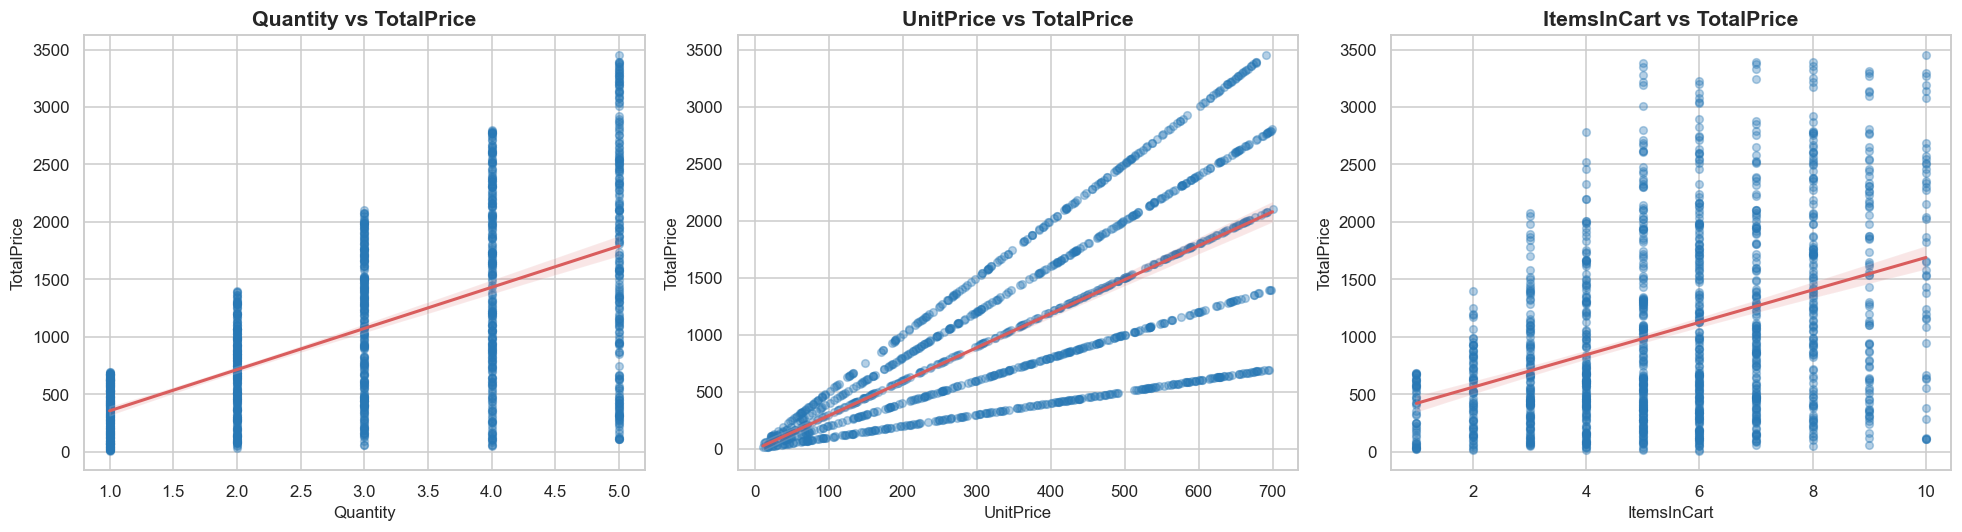

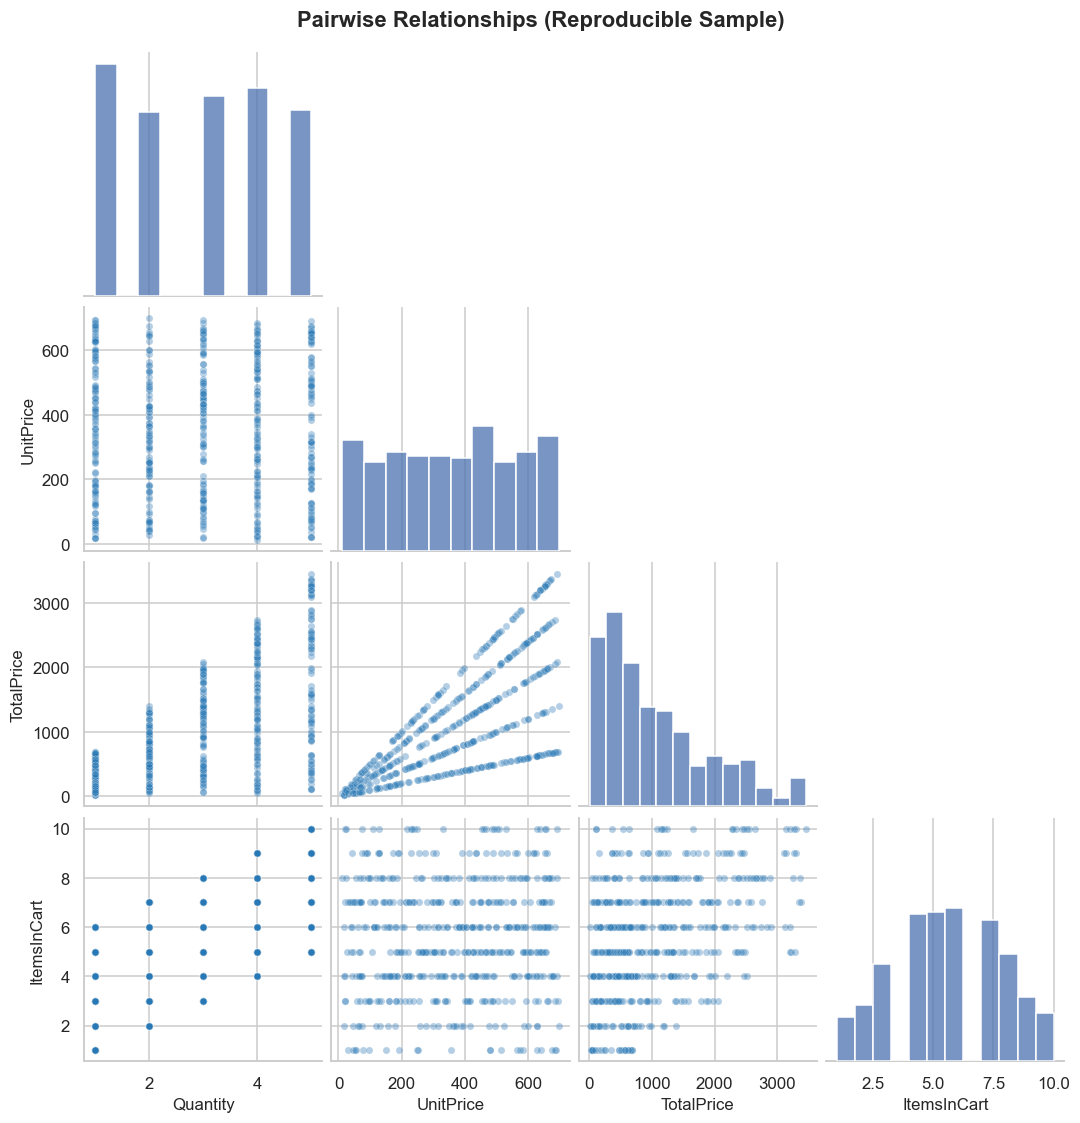

Quantity vs TotalPrice: r=0.615; larger orders increase transaction value.
UnitPrice vs TotalPrice: r=0.717; price mix is the stronger linear GOV driver.
ItemsInCart vs TotalPrice: r=0.393; cart size has a moderate relationship with GOV, but the dataset cannot reveal which cart items were abandoned or purchased.


In [22]:
pairs = [
    ("Quantity", "TotalPrice"),
    ("UnitPrice", "TotalPrice"),
    ("ItemsInCart", "TotalPrice"),
]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (x, y) in zip(axes, pairs):
    sns.regplot(
        data=df, x=x, y=y, ax=ax,
        scatter_kws={"alpha": 0.35, "s": 25, "color": COLORS["blue"]},
        line_kws={"color": COLORS["red"], "linewidth": 2}
    )
    ax.set_title(f"{x} vs {y}")
plt.tight_layout()
plt.show()

pairplot_sample = df[relationship_columns].sample(min(500, len(df)), random_state=42)
sns.pairplot(
    pairplot_sample, vars=relationship_columns,
    corner=True, plot_kws={"alpha": 0.35, "s": 22, "color": COLORS["blue"]}
)
plt.suptitle("Pairwise Relationships (Reproducible Sample)", y=1.02, fontweight="bold")
plt.show()

print(
    f"Quantity vs TotalPrice: r={correlation.loc['Quantity','TotalPrice']:.3f}; "
    "larger orders increase transaction value."
)
print(
    f"UnitPrice vs TotalPrice: r={correlation.loc['UnitPrice','TotalPrice']:.3f}; "
    "price mix is the stronger linear GOV driver."
)
print(
    f"ItemsInCart vs TotalPrice: r={correlation.loc['ItemsInCart','TotalPrice']:.3f}; "
    "cart size has a moderate relationship with GOV, but the dataset cannot reveal which cart items "
    "were abandoned or purchased."
)

## 11. Executive Insights

The following insights are generated from the analysis objects above so that the narrative stays
synchronized with the source data.

In [23]:
total_gov = df["TotalPrice"].sum()
aov = df["TotalPrice"].mean()
median_order = df["TotalPrice"].median()
product_leader = product.index[0]
product_laggard = product.index[-1]
iqr_total_count = int(outlier_masks[("TotalPrice", "IQR")].sum())
z_total_count = int(outlier_masks[("TotalPrice", "Z-Score")].sum())

insights = [
    f"1. The database contains {len(df):,} orders worth {money(total_gov)} in GOV, with an AOV of {money(aov)}.",
    f"2. Median order value is {money(median_order)}, below the mean; right skew shows that premium orders lift average performance.",
    f"3. {product_leader} leads products with {money(product.loc[product_leader,'GrossOrderValue'])} "
    f"({product.loc[product_leader,'RevenueContributionPct']:.2f}% of GOV).",
    f"4. {product_laggard} ranks lowest with {money(product.loc[product_laggard,'GrossOrderValue'])} "
    f"({product.loc[product_laggard,'RevenueContributionPct']:.2f}% of GOV).",
    f"5. The top three products contribute {top_three_share:.2f}% of GOV, indicating a diversified product base.",
    f"6. Cancelled and returned orders represent {money(at_risk)} ({at_risk_share:.2f}%) of GOV, creating major realization risk.",
    f"7. Only {repeat_count} of {len(customer):,} customers repeat ({repeat_rate:.2f}%); repeat customers contribute "
    f"{repeat_revenue_share:.2f}% of GOV.",
    f"8. The top 10 customers contribute {top_10_share:.2f}% of GOV and the top 20% contribute {top_20_share:.2f}%, "
    "so customer concentration risk is limited.",
    f"9. {referral_gov_leader} is the largest referral source at "
    f"{money(referral.loc[referral_gov_leader,'GrossOrderValue'])} "
    f"({referral.loc[referral_gov_leader,'ContributionPct']:.2f}% of GOV).",
    f"10. {payment_aov_leader} has the highest payment-method AOV at "
    f"{money(payment.loc[payment_aov_leader,'AverageOrderValue'])}.",
    f"11. IQR flags {iqr_total_count} high-value transactions, while Z-score flags {z_total_count}; "
    "all reconcile mathematically and should be retained.",
    f"12. Unit price correlates more strongly with total price (r={correlation.loc['UnitPrice','TotalPrice']:.3f}) "
    f"than quantity does (r={correlation.loc['Quantity','TotalPrice']:.3f}).",
    f"13. 2024 GOV changed {full_year_change_2024:.2f}% versus 2023, and H1 2025 changed "
    f"{h1_change_2025:.2f}% versus H1 2024.",
    f"14. {peak_month:%B %Y} was the strongest month at {money(monthly.loc[peak_month,'Revenue'])}; "
    f"{low_month:%B %Y} was the weakest at {money(monthly.loc[low_month,'Revenue'])}.",
]
display(Markdown("\n\n".join(insights)))

1. The database contains 1,200 orders worth $1,264,761.96 in GOV, with an AOV of $1,053.97.

2. Median order value is $823.62, below the mean; right skew shows that premium orders lift average performance.

3. Chair leads products with $195,620.11 (15.47% of GOV).

4. Phone ranks lowest with $151,722.39 (12.00% of GOV).

5. The top three products contribute 46.12% of GOV, indicating a diversified product base.

6. Cancelled and returned orders represent $519,673.91 (41.09%) of GOV, creating major realization risk.

7. Only 11 of 1,189 customers repeat (0.93%); repeat customers contribute 1.54% of GOV.

8. The top 10 customers contribute 2.85% of GOV and the top 20% contribute 45.42%, so customer concentration risk is limited.

9. Instagram is the largest referral source at $275,285.45 (21.77% of GOV).

10. Credit Card has the highest payment-method AOV at $1,127.55.

11. IQR flags 8 high-value transactions, while Z-score flags 0; all reconcile mathematically and should be retained.

12. Unit price correlates more strongly with total price (r=0.717) than quantity does (r=0.615).

13. 2024 GOV changed -13.10% versus 2023, and H1 2025 changed -9.79% versus H1 2024.

14. June 2024 was the strongest month at $68,068.54; April 2023 was the weakest at $27,751.71.

## 12. Business Recommendations

Recommendations are structured as **observation → business impact → action**. They prioritize issues
that are measurable in this dataset while explicitly identifying where additional data is needed.

In [24]:
recommendations = pd.DataFrame([
    (
        "Revenue Growth",
        f"2024 GOV changed {full_year_change_2024:.2f}% vs 2023 and H1 2025 changed {h1_change_2025:.2f}% vs H1 2024.",
        "Sustained softening would reduce scale even though AOV remains substantial.",
        "Create a monthly GOV bridge separating order volume, quantity, and price mix; investigate the months with the largest declines."
    ),
    (
        "Revenue Growth",
        f"{payment_aov_leader} orders have the highest payment-method AOV at {money(payment.loc[payment_aov_leader,'AverageOrderValue'])}.",
        "Checkout behavior may be associated with higher-value baskets.",
        "Test payment messaging or incentives while monitoring fees, approval rates, margin, and causal lift."
    ),
    (
        "Customer Retention",
        f"Only {repeat_rate:.2f}% of customers repeat and they generate {repeat_revenue_share:.2f}% of GOV.",
        "Growth depends heavily on continuous acquisition rather than compounding customer value.",
        "Launch a 30/60/90-day second-purchase program and track cohort repeat rate, time to second order, and incremental margin."
    ),
    (
        "Customer Retention",
        f"Top-customer concentration is low: the top 10 contribute {top_10_share:.2f}% of GOV.",
        "The business has limited individual-customer dependency but few obvious loyalty anchors.",
        "Build behavior-based segments using product, AOV, channel, and status rather than relying only on a small VIP list."
    ),
    (
        "Marketing",
        f"{referral_gov_leader} leads GOV, while {referral_aov_leader} leads referral-source AOV.",
        "The highest-volume source is not necessarily the source with the highest order quality.",
        "Allocate budget using contribution margin, customer acquisition cost, fulfillment outcome, and repeat rate by source."
    ),
    (
        "Marketing",
        f"Coupon and non-coupon AOVs are {money(coupon_users_aov)} and {money(no_coupon_aov)}, respectively.",
        "A descriptive AOV difference does not prove that discounts create incremental value.",
        "Use campaign holdouts and margin-adjusted lift to evaluate coupon effectiveness before scaling promotions."
    ),
    (
        "Product Strategy",
        f"{product_leader} leads GOV; {product_laggard} contributes the least.",
        "Inventory and merchandising choices should reflect both demand and value contribution.",
        "Protect availability for leading products and review the laggard's traffic, conversion, price competitiveness, returns, and margin."
    ),
    (
        "Product Strategy",
        f"The top three products account for {top_three_share:.2f}% of GOV.",
        "Revenue is diversified, reducing single-product risk but making broad optimization important.",
        "Use product-level bundles and cross-sell tests; avoid over-concentrating investment in one SKU without margin evidence."
    ),
    (
        "Operations",
        f"Cancelled and returned orders account for {at_risk_share:.2f}% of GOV.",
        "Booked value may substantially overstate realized revenue and operational efficiency.",
        "Capture cancellation and return reasons, refund value, delivery timing, and net revenue; prioritize root-cause reduction by product and channel."
    ),
], columns=["Category", "Observation", "Business Impact", "Recommended Action"])
display(recommendations)

,Category,Observation,Business Impact,Recommended Action
0,Revenue Growth,2024 GOV changed -13.10% vs 2023 and H1 2025 c...,Sustained softening would reduce scale even th...,Create a monthly GOV bridge separating order v...
1,Revenue Growth,Credit Card orders have the highest payment-me...,Checkout behavior may be associated with highe...,Test payment messaging or incentives while mon...
2,Customer Retention,Only 0.93% of customers repeat and they genera...,Growth depends heavily on continuous acquisiti...,Launch a 30/60/90-day second-purchase program ...
3,Customer Retention,Top-customer concentration is low: the top 10 ...,The business has limited individual-customer d...,"Build behavior-based segments using product, A..."
4,Marketing,"Instagram leads GOV, while Facebook leads refe...",The highest-volume source is not necessarily t...,"Allocate budget using contribution margin, cus..."
5,Marketing,"Coupon and non-coupon AOVs are $1,057.64 and $...",A descriptive AOV difference does not prove th...,Use campaign holdouts and margin-adjusted lift...
6,Product Strategy,Chair leads GOV; Phone contributes the least.,Inventory and merchandising choices should ref...,Protect availability for leading products and ...
7,Product Strategy,The top three products account for 46.12% of GOV.,"Revenue is diversified, reducing single-produc...",Use product-level bundles and cross-sell tests...
8,Operations,Cancelled and returned orders account for 41.0...,Booked value may substantially overstate reali...,"Capture cancellation and return reasons, refun..."


## 13. Conclusion

The dataset is technically strong: identifiers are unique, required fields are complete after interpreting
blank coupon codes, numeric values are valid, and revenue arithmetic reconciles. The commercial picture is
more challenging. Gross order value is diversified across products, channels, and customers, but repeat
purchasing is exceptionally rare and cancelled/returned orders represent a large share of booked value.

The strongest near-term opportunities are therefore to:

1. Convert first-time buyers into measurable second purchases.
2. Reduce cancellation and return exposure before equating bookings with realized revenue.
3. Manage products and channels using both scale and order quality.
4. Investigate the like-for-like revenue decline with a volume, price, and mix framework.

The analysis also defines the next data maturity step: add margin, refund, fulfillment-time, campaign-cost,
and return-reason fields. Those measures would turn this EDA into a reliable profitability and retention
decision system.